# Подгрузка библиотек

In [ ]:
# основные
import numpy as np
import pandas as pd
# метрики
from sklearn.metrics import accuracy_score, confusion_matrix, mean_absolute_error
# разбиение +валидация
from sklearn.model_selection import train_test_split, cross_val_score, cross_validate
# кадировки
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder
# визуализация
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler # маштабирование(стандартизация)

#  подгрузка базы


# Титаник

In [ ]:
df = pd.read_excel('titanic.xlsx', sheet_name='1') # смотреть кто выжил или нет  Y= Survived
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


#Подготовка данных

In [ ]:
# удаление дубликатов
df = df.drop_duplicates()

In [ ]:
df.isnull().sum() # просмотр пустых

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
# заполняем числовые средним значением
df[['Age']]= df[['Age']].fillna(df[['Age']].mean())

In [ ]:
 # Удаление строк, содержащих NaN
# df = df.dropna()  # мы уже заменили средним


In [ ]:
df.info()# просмотр пустых

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


# Кодировка

In [ ]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000000,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000000,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000000,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000000,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.000000,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.000000,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.000000,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,29.699118,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.000000,0,0,111369,30.0000,C148,C


In [ ]:
label_encoder = LabelEncoder()
# Обучим LabelEncoder на столбце 'цвет' и преобразуем его
df['Sex'] = label_encoder.fit_transform(df['Sex'])


# визуализация

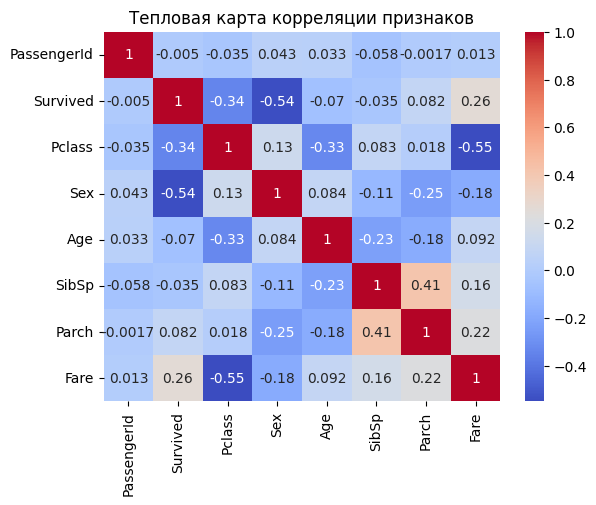

In [ ]:
# Посмотрим корреляцию наших данных   взаимосвязь одно с другим
correlation_matrix = df.corr(numeric_only=True) # Убираем предупреждение о нечисловых типах
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm") # annot - показывать значения корреляции
plt.title("Тепловая карта корреляции признаков")
plt.show()

In [ ]:
df = df.drop(columns=['Cabin', 'Embarked','Ticket', 'Name','PassengerId'])

In [ ]:
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
0,0,3,1,22.000000,1,0,7.2500
1,1,1,0,38.000000,1,0,71.2833
2,1,3,0,26.000000,0,0,7.9250
3,1,1,0,35.000000,1,0,53.1000
4,0,3,1,35.000000,0,0,8.0500
...,...,...,...,...,...,...,...
886,0,2,1,27.000000,0,0,13.0000
887,1,1,0,19.000000,0,0,30.0000
888,0,3,0,29.699118,1,2,23.4500
889,1,1,1,26.000000,0,0,30.0000


# подготовка X и Y и разбивка на train и test



In [ ]:
# Подготовка фичей - в X  удаляем колонку предсказания категории цены
X = df.drop(['Survived'], axis=1)
#подготовка целевой переменны-  в Y  только колонка предсказания категории цены
y = df['Survived']

In [ ]:
# проверяем потери 891 rows × 8-1=7 columns
X.shape

(891, 6)

# Маштабирование

In [ ]:
# Создадим экземпляр StandardScaler
scaler = StandardScaler()

# Обучим StandardScaler на данных и преобразуем их
df_scaled = scaler.fit_transform(X)

# Преобразуем в DataFrame
X= pd.DataFrame(df_scaled, columns=X.columns)

# Разделение на train и text

In [ ]:
# Разбиваем на  обущающую и тестовую
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
X_train.shape

(623, 6)

In [ ]:
X_test.shape

(268, 6)